In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda

img = plt.imread("photo.jpg")
h, w, _ = img.shape
print(img.shape)


(800, 1200, 3)


In [ ]:
@cuda.jit
def rgb2hsv(src, H, S, V):
    x = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    y = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
    if y < src.shape[0] and x < src.shape[1]:
        r = src[y, x, 0] / 255
        g = src[y, x, 1] / 255
        b = src[y, x, 2] / 255

        mx = max(r, max(g, b))
        mn = min(r, min(g, b))
        delta = mx - mn

        if delta == 0:
            hue = 0.0
        elif mx == r:
            hue = 60 * ((g - b) / delta)
        elif mx == g:
            hue = 60 * ((b - r) / delta + 2)
        else:
            hue = 60 * ((r - g) / delta + 4)
        if hue < 0:
            hue = hue + 360

        if mx == 0:
            sat = 0.0
        else:
            sat = delta / mx

        H[y, x] = hue
        S[y, x] = sat
        V[y, x] = mx


In [ ]:
@cuda.jit
def hsv2rgb(H, S, V, dst):
    x = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    y = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
    if y < dst.shape[0] and x < dst.shape[1]:
        hue = H[y, x]
        sat = S[y, x]
        val = V[y, x]

        d = hue / 60
        hi = int(d) % 6
        f = d - int(d)
        l = val * (1 - sat)
        m = val * (1 - f * sat)
        n = val * (1 - (1 - f) * sat)

        if hi == 0:
            r, g, b = val, n, l
        elif hi == 1:
            r, g, b = m, val, l
        elif hi == 2:
            r, g, b = l, val, n
        elif hi == 3:
            r, g, b = l, m, val
        elif hi == 4:
            r, g, b = n, l, val
        else:
            r, g, b = val, l, m

        dst[y, x, 0] = np.uint8(r * 255 + 0.5)
        dst[y, x, 1] = np.uint8(g * 255 + 0.5)
        dst[y, x, 2] = np.uint8(b * 255 + 0.5)


In [ ]:
devImg = cuda.to_device(img)
devH = cuda.device_array((h, w), np.float32)
devS = cuda.device_array((h, w), np.float32)
devV = cuda.device_array((h, w), np.float32)
devBack = cuda.device_array((h, w, 3), np.uint8)

block = (16, 16)
grid = ((w + 15) // 16, (h + 15) // 16)

rgb2hsv[grid, block](devImg, devH, devS, devV)
hsv2rgb[grid, block](devH, devS, devV, devBack)
cuda.synchronize()

H = devH.copy_to_host()
S = devS.copy_to_host()
V = devV.copy_to_host()
back = devBack.copy_to_host()

print("H range:", H.min(), "-", H.max())
print("S range:", S.min(), "-", S.max())
print("V range:", V.min(), "-", V.max())
print("Max diff with input:", np.abs(back.astype(int) - img.astype(int)).max())


H range: 0.0 - 359.67743
S range: 0.0 - 1.0
V range: 0.0 - 1.0
Max diff with input: 0


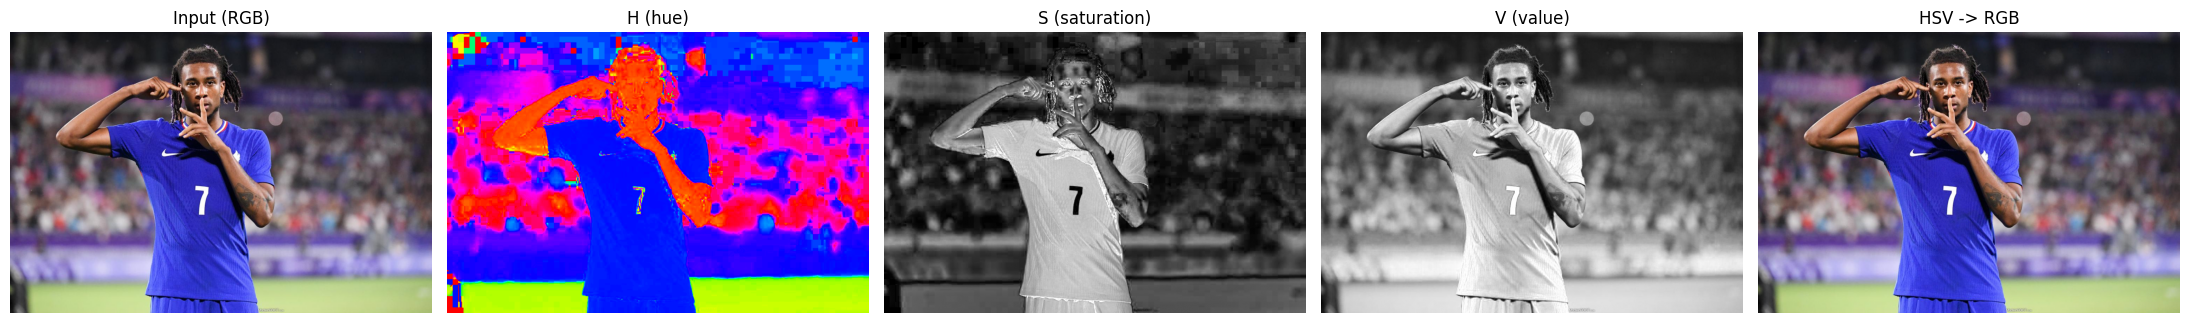

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
axes[0].imshow(img)
axes[0].set_title("Input (RGB)")
axes[1].imshow(H, cmap="hsv", vmin=0, vmax=360)
axes[1].set_title("H (hue)")
axes[2].imshow(S, cmap="gray", vmin=0, vmax=1)
axes[2].set_title("S (saturation)")
axes[3].imshow(V, cmap="gray", vmin=0, vmax=1)
axes[3].set_title("V (value)")
axes[4].imshow(back)
axes[4].set_title("HSV -> RGB")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.savefig("results.png")
plt.show()
